# Kinetics++ (Single-GPU) — End-to-End Results Notebook

This notebook builds **Kinetics-style Figure 4** replacements for Kinetics++ by:
- Evaluating a CTTS cost model across **(model, generation length, offload ratio)** grids
- Enforcing a **VRAM feasibility constraint** (single GPU)
- Computing **Pareto frontiers** (accuracy vs cost)
- Visualizing the **optimal schedule**: $L_{out}^*(C)$ and $K^*(C)$
- Producing a **systems insight** heatmap (offload-cost fraction)
- Producing a **case study** showing when offloading unlocks otherwise infeasible long generations

> Replace the `results` dictionary with your measured accuracies. Calibrate memory constants if you have profiler data.


In [3]:

# =========================
# Imports & Setup
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
np.random.seed(0)


## 1) Inputs: models + measured accuracy
Put your **measured accuracy** values keyed by generation length (tokens).

In [4]:

# =========================
# Measured results (replace with your data)
# =========================
results = {
    "Qwen-3-1.7B": {
        "P": 2e9,
        "L": 28,
        "r": 2,
        "acc": {
            2048: 0.10, 4096: 0.27, 6144: 0.27, 8192: 0.30,
            10240: 0.30, 12288: 0.30, 14336: 0.30,
            16384: 0.33, 18432: 0.33, 20480: 0.33,
            22528: 0.33, 24576: 0.33,
            28768: 0.33, 30768: 0.33, 32768: 0.33,
        }
    },
    "Qwen-3-4B": {
        "P": 4e9,
        "L": 36,
        "r": 4,
        "acc": {
            2048: 0.033, 4096: 0.200, 6144: 0.333, 8192: 0.367,
            10240: 0.433, 12288: 0.500, 14336: 0.533,
            16384: 0.533, 18432: 0.567, 20480: 0.567,
            22528: 0.600, 24576: 0.600,
            28296: 0.600, 32296: 0.600,
        }
    },
    "Qwen-3-8B": {
        "P": 8.2e9,
        "L": 36,
        "r": 4,
        "acc": {
            2048: 0.1333, 4096: 0.2000, 6144: 0.3333,
            8192: 0.4000, 10240: 0.4000, 12288: 0.4667,
            14336: 0.5000, 16384: 0.5667,
            18432: 0.5667, 20480: 0.5667,
            22528: 0.5667, 24576: 0.6000,
            28768: 0.6333, 30768: 0.6333, 32768: 0.6333,
        }
    },
    "Qwen-3-14B": {
        "P": 14.8e9,
        "L": 40,
        "r": 5,
        "acc": {
            2048: 0.0667, 4096: 0.1667, 6144: 0.3333,
            8192: 0.5000, 10240: 0.6000, 12288: 0.6000,
            14336: 0.6333, 16384: 0.6333,
            18432: 0.6333, 20480: 0.6333,
            22528: 0.6333, 24576: 0.6333,
            28768: 0.6333, 30768: 0.6333, 32768: 0.6333,
        }
    },
}


## 2) Cost model + decomposition
Returns **total cost** plus a breakdown (compute / memory / offload).

In [5]:

# =========================
# Kinetics++ CTTS cost model (with decomposition)
# =========================
def ctts_cost_components(
    *,
    P,                # total params
    L,                # num layers
    D,                # KV dimension proxy
    r,                # GQA ratio
    Lin,              # prompt length
    Lout,             # generation length
    N,                # num trials
    Igpu,             # GPU memory intensity
    Icomm,            # CPU-GPU comm intensity
    K,                # num offloaded layers
    bytes_per_param=2 # FP16
):
    P_layer = P / L
    bP_layer = bytes_per_param * P_layer

    linear_compute = 2 * N * P * Lout

    attention_compute = (
        2 * r * N * Lin * D * Lout +
        r * N * D * (Lout ** 2)
    )

    memory_cost = Igpu * (
        2 * P * Lout +
        2 * Lin * D * Lout +
        N * D * (Lout ** 2)
    )

    offload_cost = Icomm * (
        bP_layer * K * (Lin + N * Lout)
    )

    total = linear_compute + attention_compute + memory_cost + offload_cost
    parts = {"linear": linear_compute, "attention": attention_compute, "memory": memory_cost, "offload": offload_cost}
    return total, parts


## 3) VRAM feasibility model (single GPU)
Proxy feasibility constraint: resident weights + KV cache + overhead must fit in VRAM.

In [6]:

# =========================
# VRAM feasibility proxy
# =========================
def vram_feasible(
    *,
    P, L, K,
    Lin, Lout,
    D_kv,                 # KV dimension per token per layer (K+V combined)
    bytes_per_param=2,    # FP16 weights
    bytes_per_kv=2,       # FP16 KV cache; change if using FP8/INT8 KV
    gpu_vram_gb=24.0,
    overhead_gb=2.0,
    safety_frac=0.90
):
    P_layer = P / L
    w_per_layer_bytes = bytes_per_param * P_layer

    w_res_bytes = (L - K) * w_per_layer_bytes
    kv_bytes = (L - K) * (Lin + Lout) * D_kv * bytes_per_kv

    total_bytes = w_res_bytes + kv_bytes + overhead_gb * (1024**3)
    cap_bytes = gpu_vram_gb * (1024**3) * safety_frac

    breakdown = {
        "weights_gb": w_res_bytes / (1024**3),
        "kv_gb": kv_bytes / (1024**3),
        "overhead_gb": overhead_gb,
        "total_gb": total_bytes / (1024**3),
        "cap_gb": cap_bytes / (1024**3),
    }
    return total_bytes <= cap_bytes, breakdown


## 4) Experiment constants
Set prompt length, KV dimension proxy, intensities, and offloading grid.

In [7]:

# =========================
# Experiment constants
# =========================
Lin = 512
N = 1

# KV dimension proxy:
# If you know head_dim and num_kv_heads, set:
# D_kv = 2 * head_dim * num_kv_heads
D_kv = 128 * 8 * 2  # placeholder

Igpu = 36.16     # e.g., E_flops_A5000
Icomm = 881.6    # e.g., E_flops_CPU over PCIe

GPU_VRAM_GB = 24.0
OVERHEAD_GB = 2.0
SAFETY_FRAC = 0.90

K_fracs = np.array([0.0, 0.125, 0.25, 0.5, 0.75, 1.0])


## 5) Evaluate the grid
Compute cost, feasibility, and cost decomposition for each configuration.

In [8]:

# =========================
# Evaluate grid
# =========================
rows = []
for model_name, m in results.items():
    P, L, r = m["P"], m["L"], m["r"]

    for Lout, acc in sorted(m["acc"].items()):
        for frac in K_fracs:
            K = int(round(frac * L))
            K = min(K, L)

            feasible, mem = vram_feasible(
                P=P, L=L, K=K,
                Lin=Lin, Lout=int(Lout),
                D_kv=D_kv,
                gpu_vram_gb=GPU_VRAM_GB,
                overhead_gb=OVERHEAD_GB,
                safety_frac=SAFETY_FRAC,
            )

            total, parts = ctts_cost_components(
                P=P, L=L, D=D_kv, r=r,
                Lin=Lin, Lout=int(Lout),
                N=N, Igpu=Igpu, Icomm=Icomm,
                K=K
            )

            rows.append({
                "model": model_name,
                "P": P, "L": L, "r": r,
                "Lout": int(Lout),
                "K": int(K),
                "K_frac": float(K / L),
                "acc": float(acc),
                "cost": float(total),
                "cost_T": float(total / 1e12),
                "feasible": bool(feasible),
                "weights_gb": mem["weights_gb"],
                "kv_gb": mem["kv_gb"],
                "total_gb": mem["total_gb"],
                "linear": float(parts["linear"]),
                "attention": float(parts["attention"]),
                "memory": float(parts["memory"]),
                "offload": float(parts["offload"]),
                "offload_frac_of_total": float(parts["offload"] / total) if total > 0 else 0.0
            })

df = pd.DataFrame(rows)
df.head()


,model,P,L,r,Lout,K,K_frac,acc,cost,cost_T,feasible,weights_gb,kv_gb,total_gb,linear,attention,memory,offload,offload_frac_of_total
0,Qwen-3-1.7B,2.000000e+09,28,2,2048,0,0.000000,0.1,3.049064e+14,304.906408,True,3.725290,0.273438,5.998728,8.192000e+12,2.576980e+10,2.966886e+14,0.000000e+00,0.000000
1,Qwen-3-1.7B,2.000000e+09,28,2,2048,4,0.142857,0.1,1.594561e+15,1594.561265,True,3.193106,0.234375,5.427481,8.192000e+12,2.576980e+10,2.966886e+14,1.289655e+15,0.808784
2,Qwen-3-1.7B,2.000000e+09,28,2,2048,7,0.250000,0.1,2.561802e+15,2561.802408,True,2.793968,0.205078,4.999046,8.192000e+12,2.576980e+10,2.966886e+14,2.256896e+15,0.880980
3,Qwen-3-1.7B,2.000000e+09,28,2,2048,14,0.500000,0.1,4.818698e+15,4818.698408,True,1.862645,0.136719,3.999364,8.192000e+12,2.576980e+10,2.966886e+14,4.513792e+15,0.936724
4,Qwen-3-1.7B,2.000000e+09,28,2,2048,21,0.750000,0.1,7.075594e+15,7075.594408,True,0.931323,0.068359,2.999682,8.192000e+12,2.576980e+10,2.966886e+14,6.770688e+15,0.956907


## 6) Pareto frontier utilities
Upper envelope: keep points that strictly improve accuracy as cost increases.

In [9]:

# =========================
# Pareto frontier (maximize acc, minimize cost)
# =========================
def pareto_frontier(subdf: pd.DataFrame) -> pd.DataFrame:
    s = subdf.sort_values("cost").copy()
    best = -np.inf
    keep = []
    for _, row in s.iterrows():
        if row["acc"] > best + 1e-12:
            keep.append(True)
            best = row["acc"]
        else:
            keep.append(False)
    return s.loc[keep].copy()

feas = df[df["feasible"]].copy()


## 7) Plot A1 — Accuracy vs Cost (Kinetics-style) with Pareto frontiers

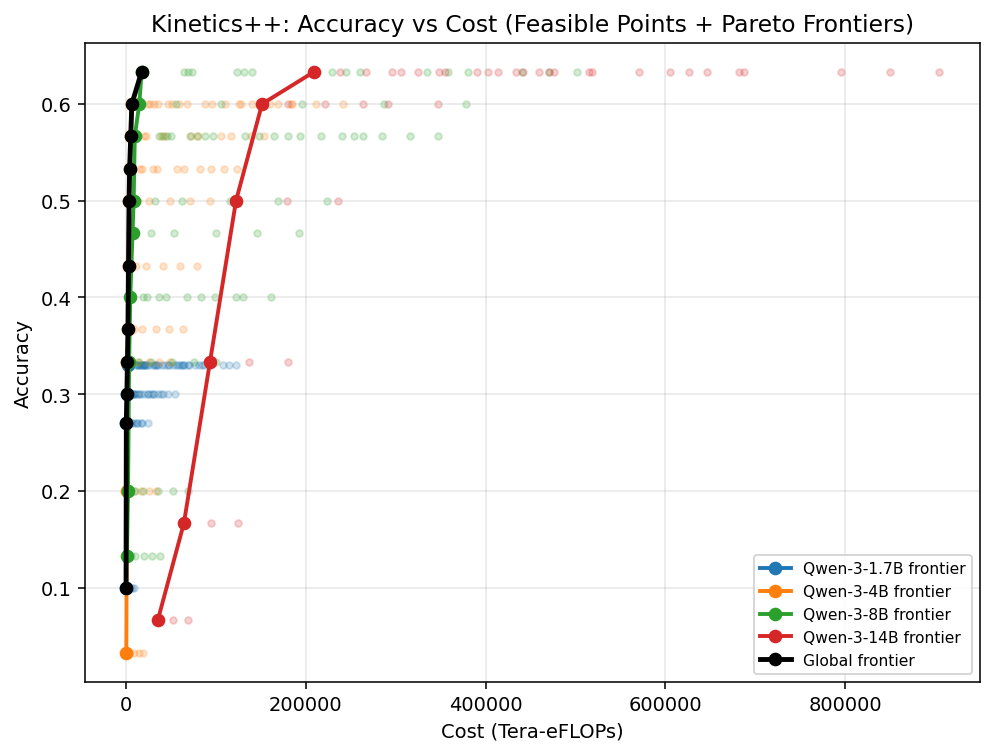

In [10]:

# =========================
# Plot A1
# =========================
plt.figure(figsize=(7.2, 5.5))

# All feasible points (faint)
for model_name in feas["model"].unique():
    sub = feas[feas["model"] == model_name]
    plt.scatter(sub["cost_T"], sub["acc"], s=12, alpha=0.20)

# Model frontiers
for model_name in feas["model"].unique():
    sub = feas[feas["model"] == model_name]
    front = pareto_frontier(sub)
    plt.plot(front["cost_T"], front["acc"], marker="o", linewidth=2, label=f"{model_name} frontier")

# Global frontier
gfront = pareto_frontier(feas)
plt.plot(gfront["cost_T"], gfront["acc"], color="black", linewidth=2.5, marker="o", label="Global frontier")

plt.xlabel("Cost (Tera-eFLOPs)")
plt.ylabel("Accuracy")
plt.title("Kinetics++: Accuracy vs Cost (Feasible Points + Pareto Frontiers)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8) Plot A2 — Optimal schedule: $L_{out}^*(C)$ and $K^*(C)$

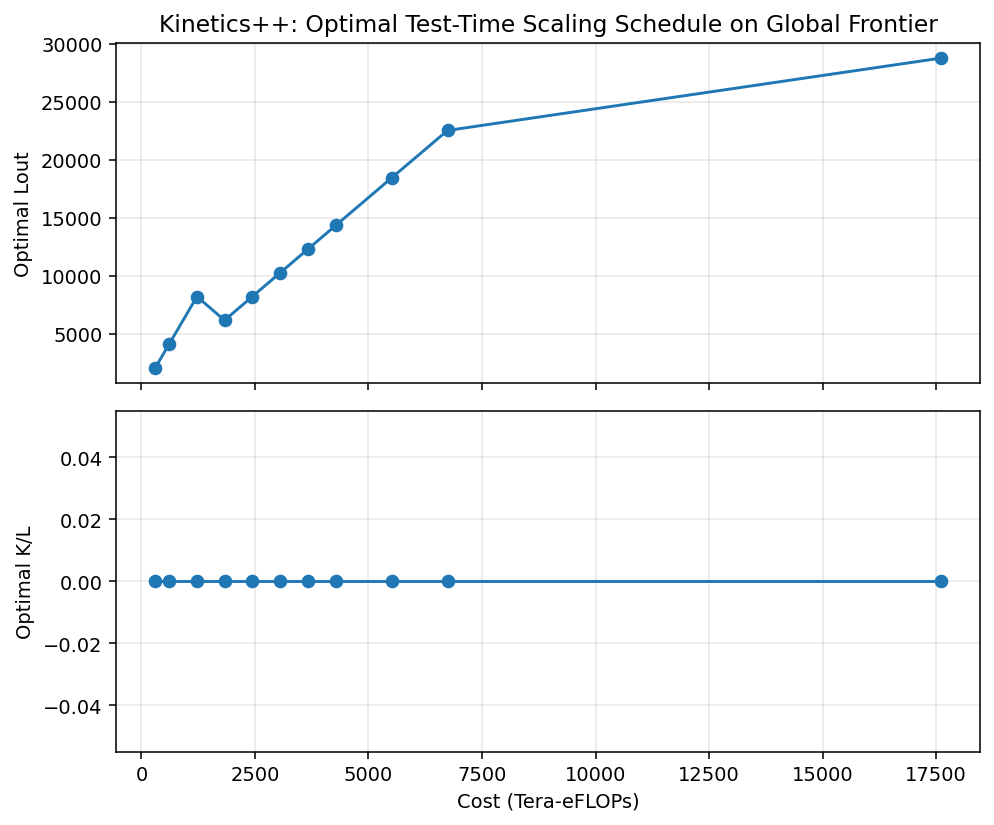

,cost_T,acc,model,Lout,K,K_frac,total_gb,offload_frac_of_total
0,304.906408,0.1000,Qwen-3-1.7B,2048,0,0.0,5.998728,0.0
6,610.468400,0.2700,Qwen-3-1.7B,4096,0,0.0,6.217478,0.0
18,1223.559134,0.3000,Qwen-3-1.7B,8192,0,0.0,6.654978,0.0
102,1830.110524,0.3330,Qwen-3-4B,6144,0,0.0,10.364643,0.0
108,2441.527252,0.3670,Qwen-3-4B,8192,0,0.0,10.645893,0.0
114,3053.633924,0.4330,Qwen-3-4B,10240,0,0.0,10.927143,0.0
120,3666.430539,0.5000,Qwen-3-4B,12288,0,0.0,11.208393,0.0
126,4279.917098,0.5330,Qwen-3-4B,14336,0,0.0,11.489643,0.0
138,5508.960047,0.5670,Qwen-3-4B,18432,0,0.0,12.052143,0.0
150,6740.762769,0.6000,Qwen-3-4B,22528,0,0.0,12.614643,0.0


In [11]:

# =========================
# Plot A2
# =========================
gfront = gfront.sort_values("cost").copy()

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.0), sharex=True)

axes[0].plot(gfront["cost_T"], gfront["Lout"], marker="o")
axes[0].set_ylabel("Optimal Lout")
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Kinetics++: Optimal Test-Time Scaling Schedule on Global Frontier")

axes[1].plot(gfront["cost_T"], gfront["K_frac"], marker="o")
axes[1].set_xlabel("Cost (Tera-eFLOPs)")
axes[1].set_ylabel("Optimal K/L")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Frontier table (for paper/appendix)
gfront[["cost_T","acc","model","Lout","K","K_frac","total_gb","offload_frac_of_total"]].head(20)


## 9) Plot B — Heatmap: offload cost fraction vs (Lout, K/L)

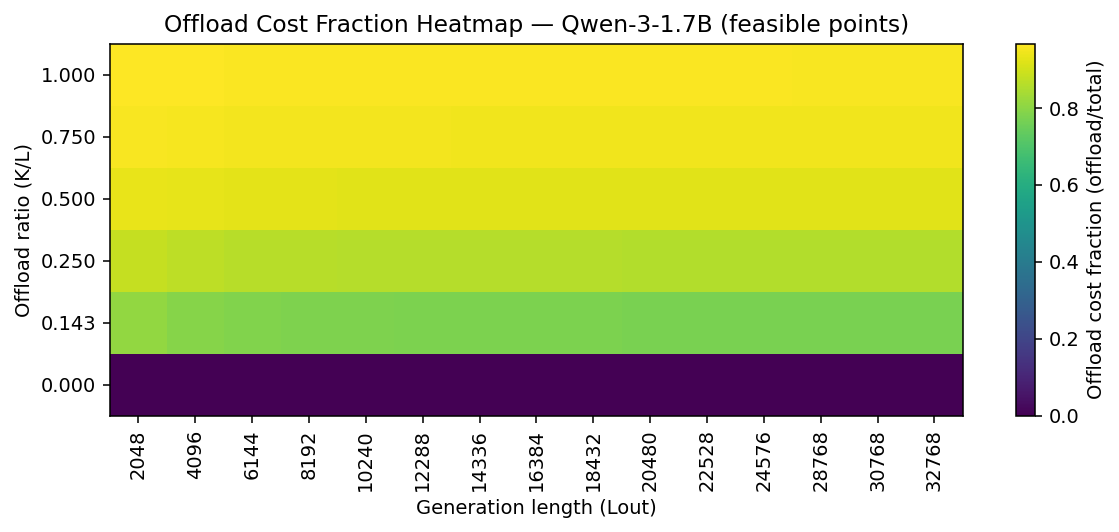

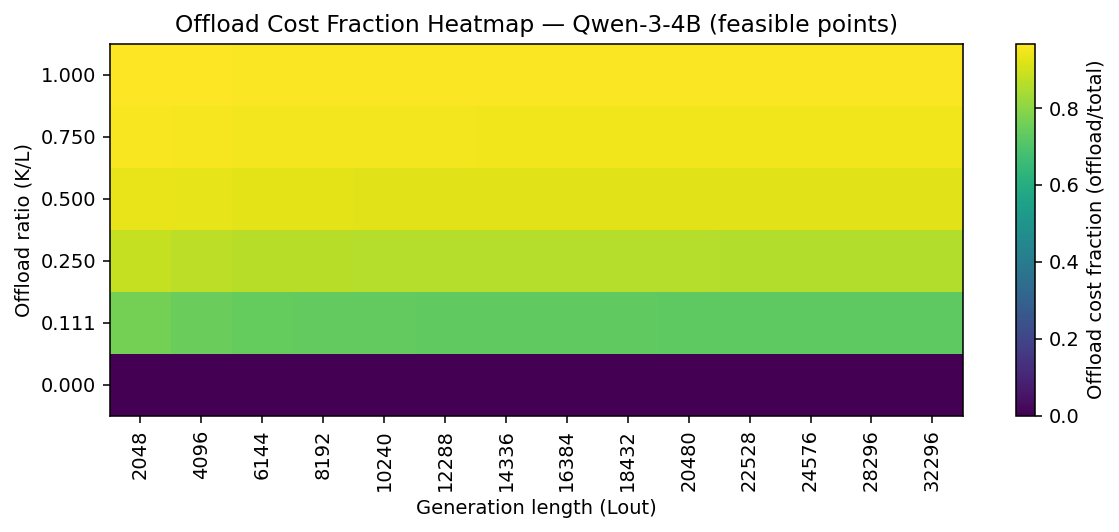

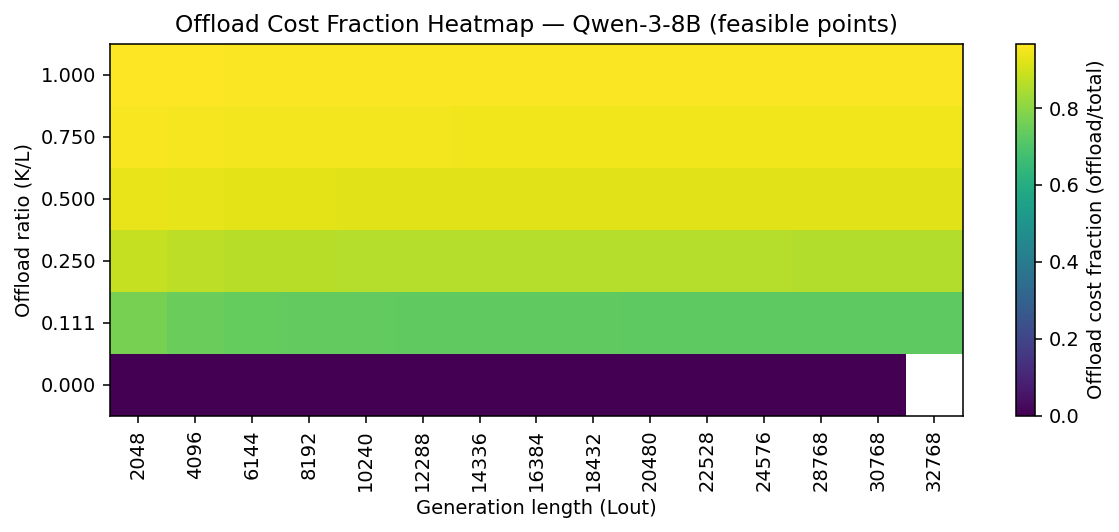

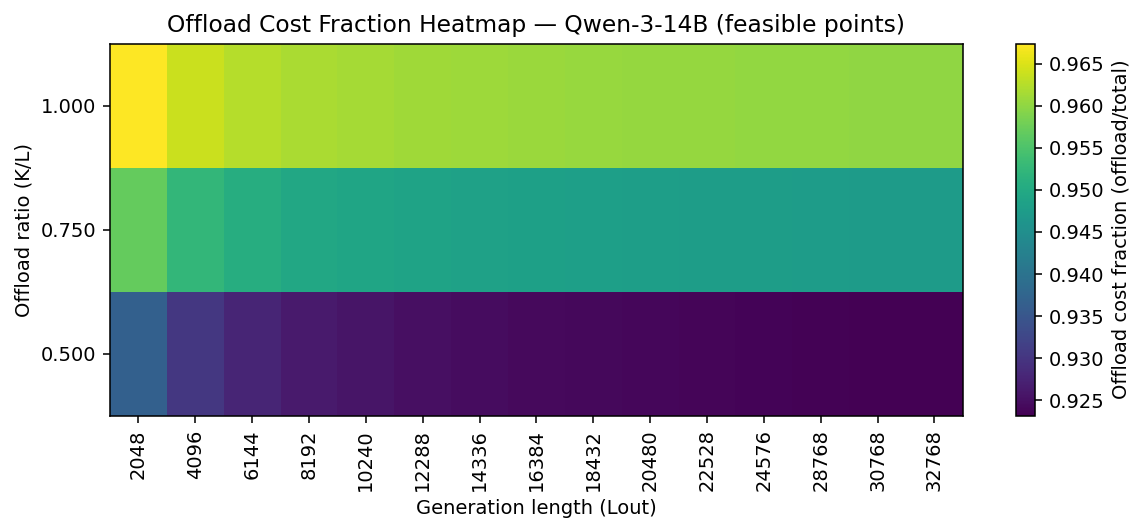

In [12]:

# =========================
# Plot B: per-model heatmap
# =========================
def heatmap_offload_fraction(model_name: str):
    sub = feas[feas["model"] == model_name].copy()
    piv = sub.pivot_table(index="K_frac", columns="Lout", values="offload_frac_of_total", aggfunc="mean")
    piv = piv.sort_index().sort_index(axis=1)

    plt.figure(figsize=(8.6, 3.9))
    plt.imshow(piv.values, aspect="auto", origin="lower")
    plt.colorbar(label="Offload cost fraction (offload/total)")
    plt.yticks(range(len(piv.index)), [f"{v:.3f}" for v in piv.index])
    plt.xticks(range(len(piv.columns)), [str(c) for c in piv.columns], rotation=90)
    plt.xlabel("Generation length (Lout)")
    plt.ylabel("Offload ratio (K/L)")
    plt.title(f"Offload Cost Fraction Heatmap — {model_name} (feasible points)")
    plt.tight_layout()
    plt.show()

for mn in results.keys():
    heatmap_offload_fraction(mn)


## 10) Plot C — Case study: offloading as feasibility unlock
Compare an 8B no-offload curve vs 14B minimal-offload-to-fit curve.

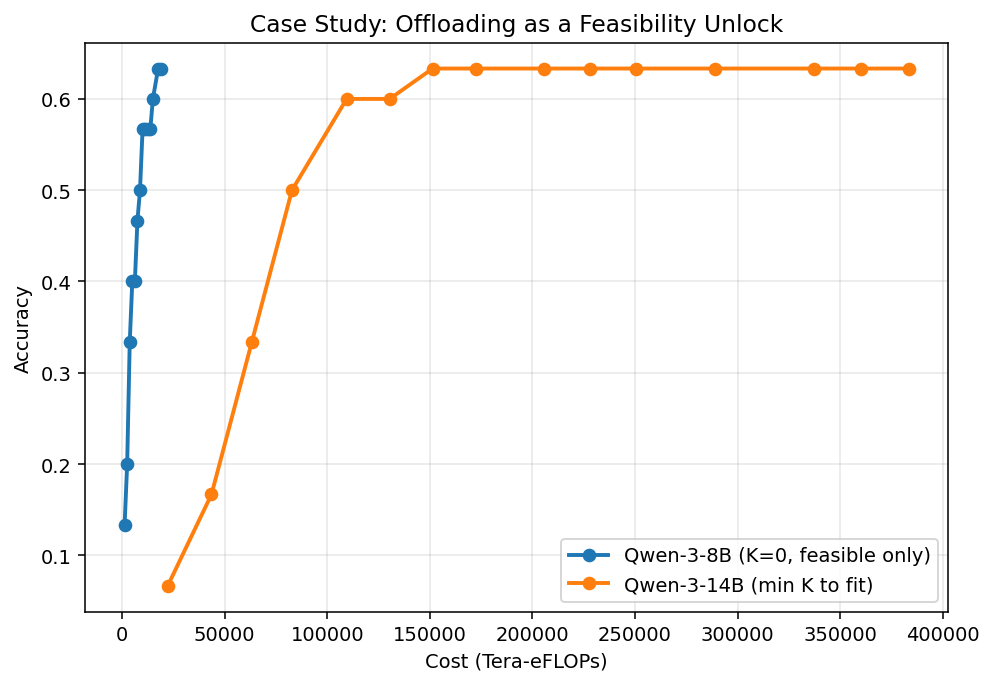

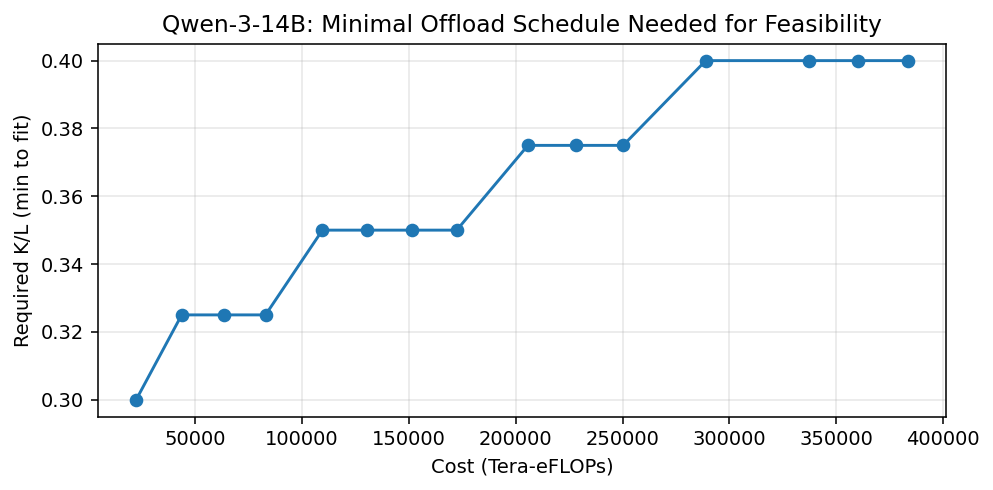

In [13]:

# =========================
# Case study: minimal offload needed to fit
# =========================
def min_offload_to_fit(model_name: str, Lout: int):
    m = results[model_name]
    P, L = m["P"], m["L"]
    for K in range(0, L + 1):
        ok, _ = vram_feasible(
            P=P, L=L, K=K,
            Lin=Lin, Lout=Lout,
            D_kv=D_kv,
            gpu_vram_gb=GPU_VRAM_GB,
            overhead_gb=OVERHEAD_GB,
            safety_frac=SAFETY_FRAC,
        )
        if ok:
            return K
    return None

def curve_with_min_offload(model_name: str):
    m = results[model_name]
    P, L, r = m["P"], m["L"], m["r"]

    xs, ys, ks = [], [], []
    for Lout, acc in sorted(m["acc"].items()):
        K = min_offload_to_fit(model_name, int(Lout))
        if K is None:
            continue
        total, _ = ctts_cost_components(
            P=P, L=L, D=D_kv, r=r,
            Lin=Lin, Lout=int(Lout),
            N=N, Igpu=Igpu, Icomm=Icomm,
            K=K
        )
        xs.append(total / 1e12)
        ys.append(acc)
        ks.append(K / L)
    return np.array(xs), np.array(ys), np.array(ks)

m1 = "Qwen-3-8B"
m2 = "Qwen-3-14B"

sub8 = df[(df["model"] == m1) & (df["K"] == 0) & (df["feasible"])].sort_values("cost")
x8, y8 = sub8["cost_T"].to_numpy(), sub8["acc"].to_numpy()

x14, y14, k14 = curve_with_min_offload(m2)

plt.figure(figsize=(7.2, 5.0))
plt.plot(x8, y8, marker="o", linewidth=2, label=f"{m1} (K=0, feasible only)")
plt.plot(x14, y14, marker="o", linewidth=2, label=f"{m2} (min K to fit)")
plt.xlabel("Cost (Tera-eFLOPs)")
plt.ylabel("Accuracy")
plt.title("Case Study: Offloading as a Feasibility Unlock")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.2, 3.6))
plt.plot(x14, k14, marker="o")
plt.xlabel("Cost (Tera-eFLOPs)")
plt.ylabel("Required K/L (min to fit)")
plt.title(f"{m2}: Minimal Offload Schedule Needed for Feasibility")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11) Optional: naive baseline (ignore offload cost term)
Recompute costs with `Icomm=0` to show how the frontier changes when you ignore offload cost.

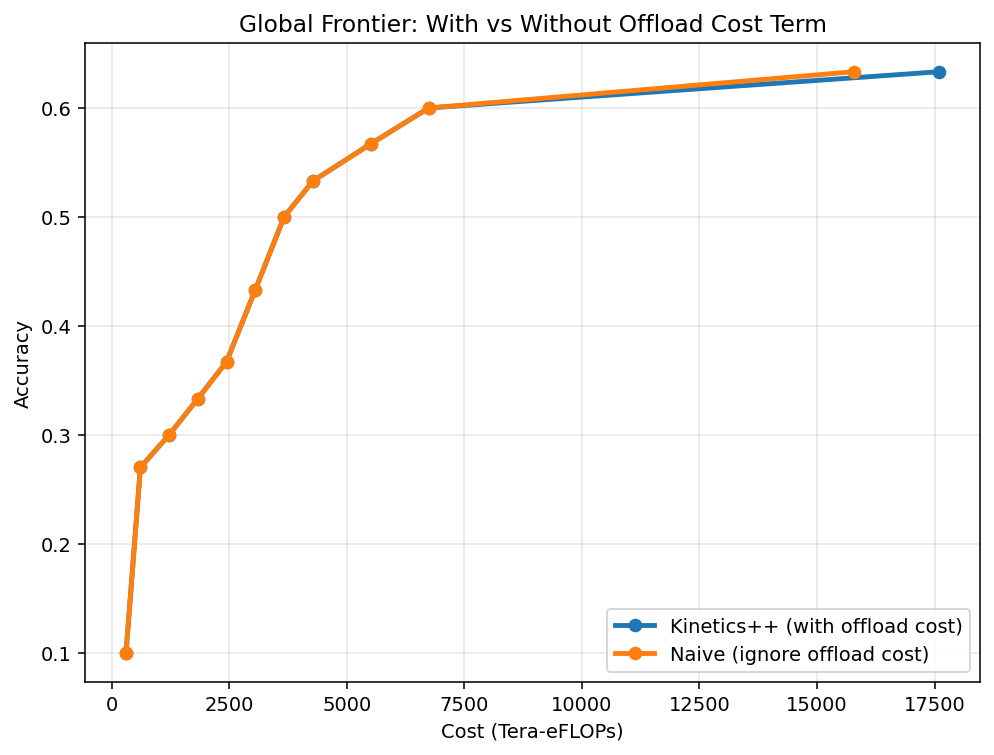

In [14]:

# =========================
# Optional: naive baseline (Icomm=0)
# =========================
rows_naive = []
for model_name, m in results.items():
    P, L, r = m["P"], m["L"], m["r"]

    for Lout, acc in sorted(m["acc"].items()):
        for frac in K_fracs:
            K = int(round(frac * L))
            K = min(K, L)

            feasible, _ = vram_feasible(
                P=P, L=L, K=K,
                Lin=Lin, Lout=int(Lout),
                D_kv=D_kv,
                gpu_vram_gb=GPU_VRAM_GB,
                overhead_gb=OVERHEAD_GB,
                safety_frac=SAFETY_FRAC,
            )

            total, _ = ctts_cost_components(
                P=P, L=L, D=D_kv, r=r,
                Lin=Lin, Lout=int(Lout),
                N=N, Igpu=Igpu, Icomm=0.0,  # ignore offload cost
                K=K
            )
            rows_naive.append({
                "model": model_name,
                "Lout": int(Lout),
                "K_frac": float(K / L),
                "acc": float(acc),
                "cost": float(total),
                "cost_T": float(total / 1e12),
                "feasible": bool(feasible),
            })

df_naive = pd.DataFrame(rows_naive)
feas_naive = df_naive[df_naive["feasible"]].copy()

gfront_naive = pareto_frontier(feas_naive)

plt.figure(figsize=(7.2, 5.5))
plt.plot(gfront["cost_T"], gfront["acc"], marker="o", linewidth=2.5, label="Kinetics++ (with offload cost)")
plt.plot(gfront_naive["cost_T"], gfront_naive["acc"], marker="o", linewidth=2.5, label="Naive (ignore offload cost)")
plt.xlabel("Cost (Tera-eFLOPs)")
plt.ylabel("Accuracy")
plt.title("Global Frontier: With vs Without Offload Cost Term")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 12) Export: compact table for paper
This prints a clean table of frontier points you can reference in your Results / Appendix.

In [ ]:

frontier_table = gfront[["cost_T","acc","model","Lout","K","K_frac","total_gb","offload_frac_of_total"]].copy()
frontier_table = frontier_table.round({
    "cost_T": 3, "acc": 4, "K_frac": 3, "total_gb": 2, "offload_frac_of_total": 3
}).sort_values("cost_T")
frontier_table.head(40)
